# Earth-like configuration

This notebook demonstrates a JAX-ESM (JEM) example using JAX-GCM (JCM), Slab Ocean Model, and Slab Land Model.

In [1]:
from pathlib import Path

import jcm
from jcm.physics.speedy.speedy_coords import get_speedy_coords
from jcm.terrain import TerrainData
from jcm.forcing import ForcingData
from importlib import resources

import jax_datetime as jdt

from jem.components import JCM, SlabLandModel, SlabOceanModel
from jem.mapping import BasicMapper
from jem.base.coupler import Coupler
import jem.utils.tree_tools as tree_tools

use_ipython = 'get_ipython' in globals()

jax._src.xla_bridge: 2026-03-10 17:52:33,113 WARNING: An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Configurations

In [2]:
start_datetime = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")
simulation_name = "02-01_earth"
output_dir = (Path("output") / simulation_name).resolve()
output_dir.mkdir(exist_ok=True, parents=True)
output_figures = {
    "animation": output_dir / "animation_humidity_sst.gif",
}
one_second = jdt.to_timedelta(1, "second")

In [3]:
# ## Topography and forcing

coords = get_speedy_coords()  # T31 spectral resolution with 8 vertical levels

# Load realistic orography and land-sea mask, interpolated to T31 grid
data_dir = resources.files("jcm.data.bc.t30.clim")
terrain_file = data_dir / "terrain.nc"
terrain = TerrainData.from_file(terrain_file, coords=coords)

# Load realistic forcing data (SST, sea ice, soil moisture, etc.) interpolated to T31 grid
forcing_file = data_dir / "forcing.nc"
forcing = ForcingData.from_file(forcing_file, coords=coords)

# Create model with realistic configuration
model = jcm.model.Model(
   coords,
   time_step=30.0,
   terrain=terrain
)

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jcm/data/bc/interpolate.py:47: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([daily_time_vars, ds_monthly[non_time_vars]])


## Creating Flux and Scalar Exchange between Components

In [4]:
import jax.numpy as jnp
mapper = BasicMapper()
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("ocn", "forcing.total_heat_flux"),
)
mapper.add_mapping(
    source = ("ocn", "state.sea_surface_temperature"),
    target = ("atm", "forcing.sea_surface_temperature"),
)
mapper.add_mapping(
    source = ("atm", "derived.total_heat_flux"),
    target = ("lnd", "forcing.total_heat_flux"),
)
mapper.add_mapping(
    source = ("lnd", "state.land_surface_temperature"),
    target = ("atm", "forcing.stl_am"),
)

# There are issues in passing snow depth and soil moisture
# content to jcm which need further improvement. For now,
# we simply ignore them.
"""
mapper.add_mapping(
    source = ("lnd", "state.snowd"),
    target = ("atm", "forcing.snowc_am"),
    regridder = lambda x: jnp.zeros_like(x),
)
mapper.add_mapping(
    source = ("lnd", "state.soilw"),
    target = ("atm", "forcing.soilw_am"),
    regridder = lambda x: jnp.zeros_like(x),
)
"""

'\nmapper.add_mapping(\n    source = ("lnd", "state.snowd"),\n    target = ("atm", "forcing.snowc_am"),\n    regridder = lambda x: jnp.zeros_like(x),\n)\nmapper.add_mapping(\n    source = ("lnd", "state.soilw"),\n    target = ("atm", "forcing.soilw_am"),\n    regridder = lambda x: jnp.zeros_like(x),\n)\n'

## Create Components

In [5]:
atm_model = jcm.model.Model(
    coords = coords, 
    start_date=start_datetime,
    terrain = terrain,
)

atm_model = JCM.make_jem_compatible(
    atm_model,
    coupling_timestep=coupling_timestep,
)

model = Coupler(
    components=dict(
        atm=atm_model,
        ocn=SlabOceanModel(
            start_datetime=start_datetime,
            mask_file=terrain_file,
            SST_clim_file=forcing_file,
            forcing_method="relaxation",
            relaxation_time= 30 * 86400.0,
        ),
        lnd=SlabLandModel(
            start_datetime=start_datetime,
            topography_file=terrain_file,
            mask_file=terrain_file,
            land_clim_file=forcing_file,
            # Strong relaxation because land model seems to have a bug such 
            # that temperature get unrealistic cold/hot.
            tdland = 86400.0, 
        ),
    ),
    mappers=dict(mapper=mapper),
)

print("Model info: ") 
tree_tools.print_tree(model.get_info(), root="Model")

Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.Callable[[], typing.Dict]`
Checking `initialize` => `typing.Callable[[], typing.Any]`
Checking `generate_step_function` => `typing.Callable[[], typing.Callable[[typing.Any, float], tuple[typing.Any, typing.Any]]]`
Checking `predictions_to_xarray` => `typing.Callable[[typing.Any], xarray.core.dataset.Dataset]`
Checking `get_info` => `typing.C

## Run Coupled Model

In [6]:
simulation_interval = jdt.to_timedelta(5, "day")
initial_state, final_state, predictions = model.run(
    workflow=["mapper", "atm", "ocn", "lnd"],
    iterations = int(simulation_interval / coupling_timestep),
)

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


SST climatology file. The given initial SST will be used.
SST climatology file:  /home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jcm/data/bc/t30/clim/forcing.nc
grid.bmask and SST_clim do share the same mask.
Initializing land masks from domain...
Total land grid count: 1857.0
Loading land climatology from: /home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jcm/data/bc/t30/clim/forcing.nc
Loaded stl climatology with shape: (96, 48, 12)
Notice: found 'snowd_am' in boundary file.
Heat capacity range: 3.46e-02 - 3.46e-02
Dissipation coefficient range: 0.000 - 0.500
Initial land temperature range: 226.97 - 310.16 K
Flattened workflow:  mapper, atm, ocn, lnd
Doing: lnd.state.land_surface_temperature -> atm.forcing.stl_am
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> lnd.forcing.total_heat_flux
Notice: Mapping for ocn -> lnd does not exist.
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_f

/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Using method: relaxation
Doing: lnd.state.land_surface_temperature -> atm.forcing.stl_am
Doing: ocn.state.sea_surface_temperature -> atm.forcing.sea_surface_temperature
Doing: atm.derived.total_heat_flux -> lnd.forcing.total_heat_flux
Notice: Mapping for ocn -> lnd does not exist.
Doing: atm.derived.total_heat_flux -> ocn.forcing.total_heat_flux
Notice: Mapping for lnd -> ocn does not exist.


/home/xtt/miniconda3/envs/jax/lib/python3.13/site-packages/jax/_src/numpy/scalar_types.py:55: UserWarning: Explicitly requested dtype int64 requested in asarray is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


Simulation:   0%|          | 0/5 [00:00<?, ?it/s]

## Output into NetCDF

In [7]:
output_dict = model.predictions_to_xarray(predictions)
output_dict_subsample = {}
subsample_skip = 5
for component_name, ds in output_dict.items():
    output_file = output_dir / f"{component_name:s}.nc"
    print(f"Output file: {str(output_file)}, with subsample_skip = {subsample_skip:d}")
    ds = ds.isel(time=slice(None, None, subsample_skip))
    ds.to_netcdf(output_file, engine="netcdf4")
    output_dict_subsample[component_name] = ds

Output file: /home/xtt/projects/project_jax-esm/jax-esm_repo/docs/notebooks/02_experimental/output/02-01_earth/atm.nc, with subsample_skip = 5
Output file: /home/xtt/projects/project_jax-esm/jax-esm_repo/docs/notebooks/02_experimental/output/02-01_earth/ocn.nc, with subsample_skip = 5
Output file: /home/xtt/projects/project_jax-esm/jax-esm_repo/docs/notebooks/02_experimental/output/02-01_earth/lnd.nc, with subsample_skip = 5


## Visualization

In [8]:
import matplotlib as mplt
if not use_ipython:
    mplt.use("Agg")
import matplotlib.pyplot as plt

Saving animation:  /home/xtt/projects/project_jax-esm/jax-esm_repo/docs/notebooks/02_experimental/output/02-01_earth/animation_humidity_sst.gif
Plotting frame=0
Plotting frame=0
Plotting frame=1
Plotting frame=2
Plotting frame=3
Plotting frame=4


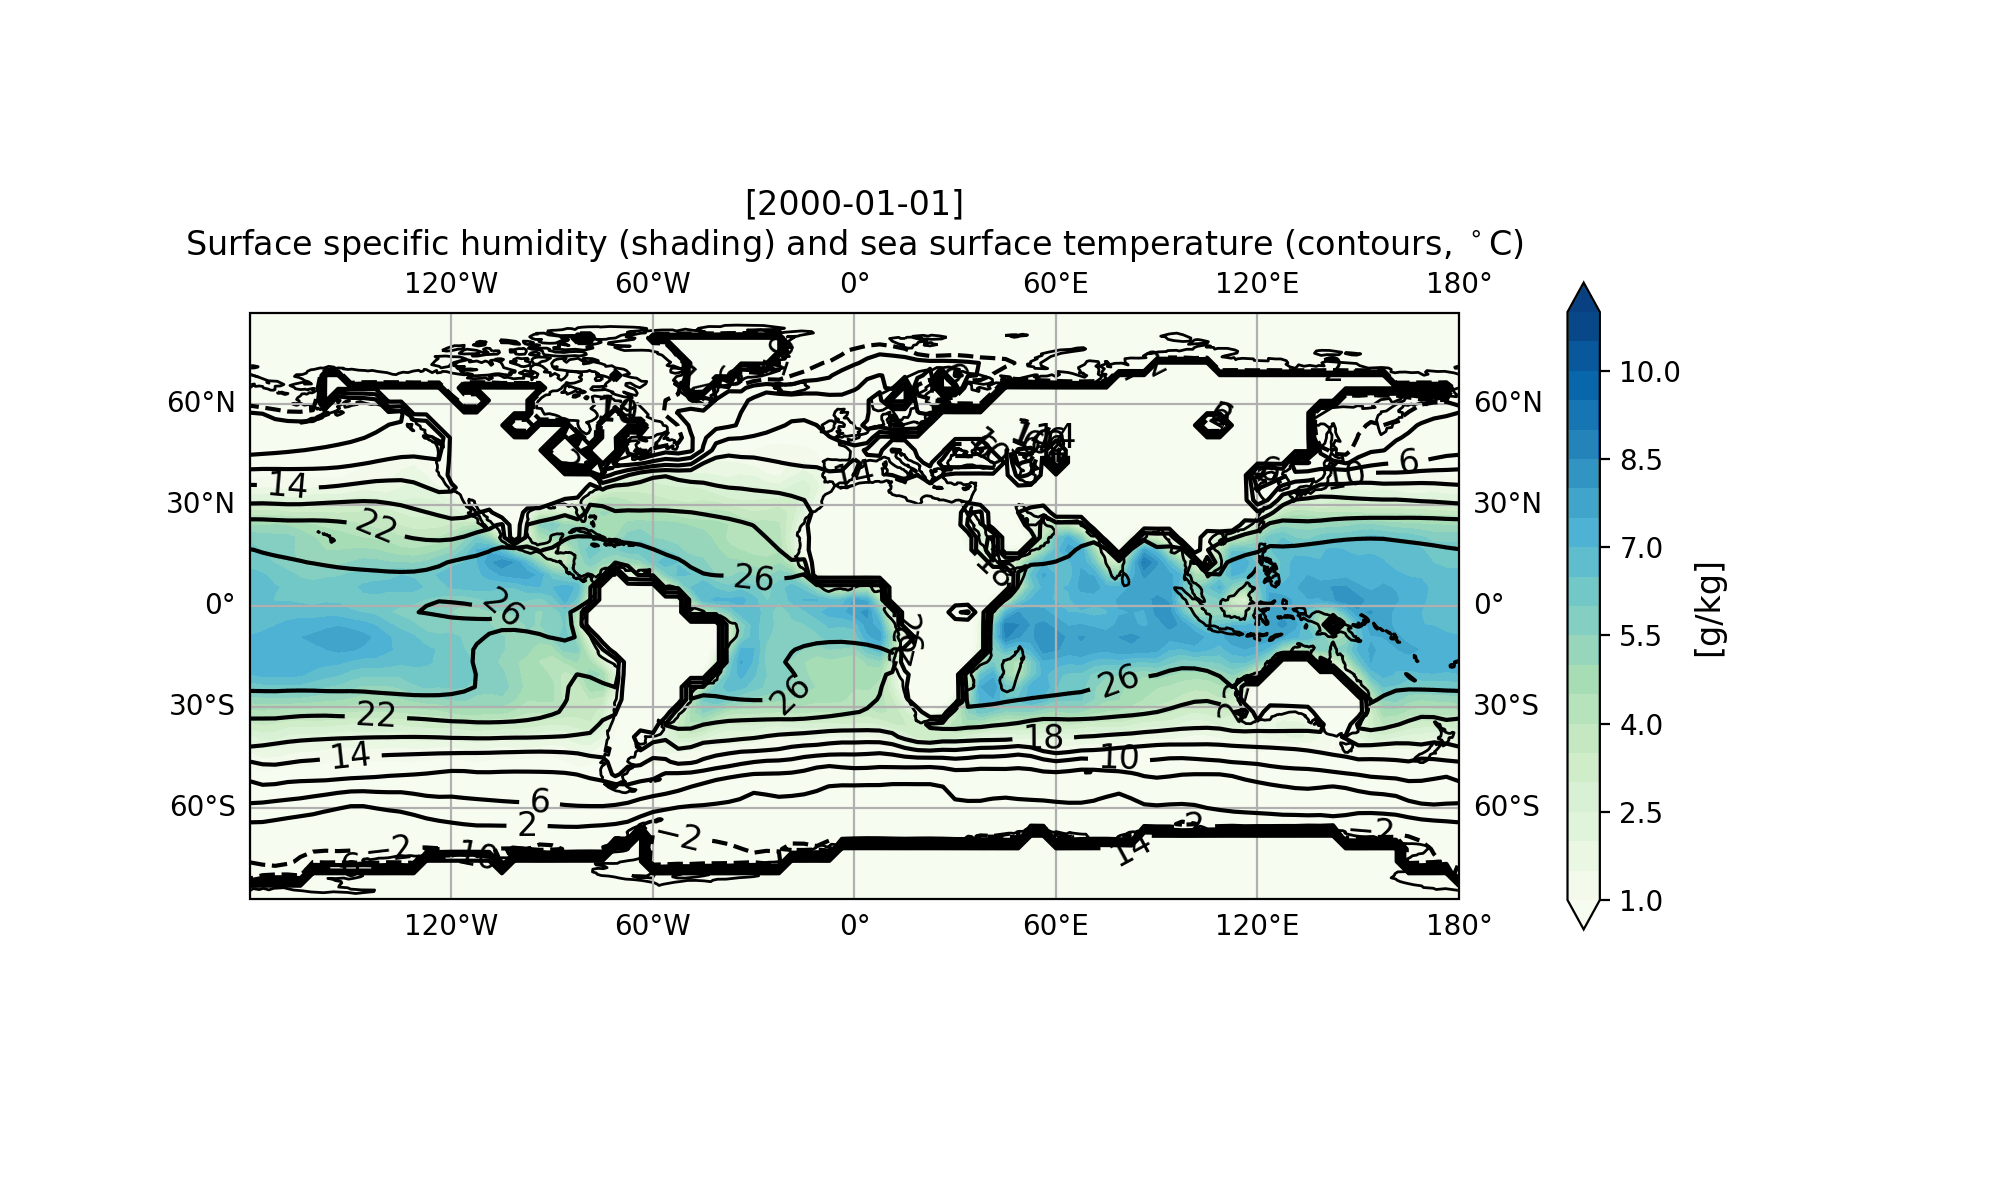

Plotting frame=0


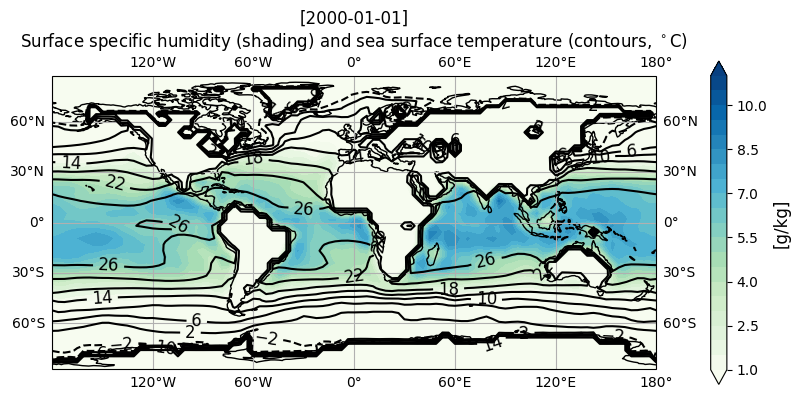

In [9]:
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import numpy as np
output_dict_animation = {
    component_name: _ds.isel(time=slice(None, None, 1))
    for component_name, _ds in output_dict.items()
}

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=True)
cb = None
cf = None
cs = None

def update(frame):
    print(f"Plotting frame={frame:d}")
    global cf, cb, cs 
    _data_q = output_dict_animation["atm"]["specific_humidity"].isel(time=frame, level=0)
    _data_sst = output_dict_animation["ocn"]["sea_surface_temperature"].isel(time=frame) - 273.15
    coords = _data_q.coords
    time_str = _data_q['time'].dt.strftime('%Y-%m-%d').to_numpy().item()
    lat = coords["lat"]
    lon = coords["lon"]

    # Remove contour and contourf if not empty
    cf and cf.remove()
    cs and cs.remove()
    
    # Plot the humidity field for the current time step
    cyclic_data_q, cyclic_lon = add_cyclic_point(_data_q.to_numpy().transpose(), coord=lon)
    mappable = ax.contourf(
        cyclic_lon, lat,
        cyclic_data_q,
        levels=1 + np.linspace(0, 1, 21) * 10,
        transform=ccrs.PlateCarree(), 
        cmap='GnBu',
        extend="both",
    )
    
    cyclic_data_sst, cyclic_lon = add_cyclic_point(_data_sst.to_numpy().transpose(), coord=lon)
    cs = ax.contour(
        cyclic_lon, lat,
        cyclic_data_sst,
        levels=np.arange(-2, 31, 4),
        transform=ccrs.PlateCarree(),
        colors="black",
    )
    ax.clabel(cs, fontsize=12)
    ax.set_title(f"[{time_str:s}]\nSurface specific humidity (shading) and sea surface temperature (contours, ${{}}^\\circ \\mathrm{{C}}$)")
    if cb is None:
        cb = plt.colorbar(ax=ax, mappable=mappable, orientation='vertical', shrink=0.7, pad=0.07)
        cb.set_label("[g/kg]", fontsize=12)
    
    return [cf,]
    
# Generate and save
ani = FuncAnimation(fig, update, frames=len(output_dict_animation["atm"].coords["time"]), interval=120, blit=False)
print("Saving animation: ", output_figures['animation'])
ani.save(output_figures['animation'], writer='pillow', dpi=200)

if use_ipython:
    from IPython.display import Image
    display(Image(output_figures['animation']))